## Turning tabular data in geospatial

In [1]:
import pandas as pd

In [2]:
tdf = pd.read_csv('2015_Street_Tree_Census_-_Tree_Data_20240618.csv', nrows = 10000)

In [3]:
len(tdf)

10000

In [4]:
tdf.head(3)

,tree_id,block_id,created_at,tree_dbh,stump_diam,curb_loc,status,health,spc_latin,spc_common,...,boro_ct,state,latitude,longitude,x_sp,y_sp,council district,census tract,bin,bbl
0,180683,348711,08/27/2015,3,0,OnCurb,Alive,Fair,Acer rubrum,red maple,...,4073900,New York,40.723092,-73.844215,1027431.148,202756.7687,29.0,739.0,4052307.0,4.022210e+09
1,200540,315986,09/03/2015,21,0,OnCurb,Alive,Fair,Quercus palustris,pin oak,...,4097300,New York,40.794111,-73.818679,1034455.701,228644.8374,19.0,973.0,4101931.0,4.044750e+09
2,204026,218365,09/05/2015,3,0,OnCurb,Alive,Good,Gleditsia triacanthos var. inermis,honeylocust,...,3044900,New York,40.717581,-73.936608,1001822.831,200716.8913,34.0,449.0,3338310.0,3.028870e+09


In [5]:
from collections import Counter

In [6]:
Counter(tdf.status).most_common()

[('Alive', 9391), ('Stump', 338), ('Dead', 271)]

In [7]:
Counter(tdf.health).most_common()

[('Good', 6918), ('Fair', 1936), (nan, 609), ('Poor', 537)]

In [8]:
from shapely.geometry import Point

In [9]:
import geopandas as gpd

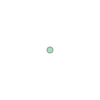

In [10]:
geometry = [Point(xy) for xy in zip(tdf['longitude'],tdf['latitude'])]
geometry[0]

In [11]:
gdf = gpd.GeoDataFrame(tdf, geometry = geometry)[['tree_id','stump_diam','status','health','geometry']]

In [12]:
gdf.crs = 4326

In [13]:
gdf.head()

,tree_id,stump_diam,status,health,geometry
0,180683,0,Alive,Fair,POINT (-73.84422 40.72309)
1,200540,0,Alive,Fair,POINT (-73.81868 40.79411)
2,204026,0,Alive,Good,POINT (-73.93661 40.71758)
3,204337,0,Alive,Good,POINT (-73.93446 40.71354)
4,189565,0,Alive,Good,POINT (-73.97598 40.66678)


(np.float64(-74.2791066075),
 np.float64(-73.68647660250001),
 np.float64(40.4790767395),
 np.float64(40.926552350499996))

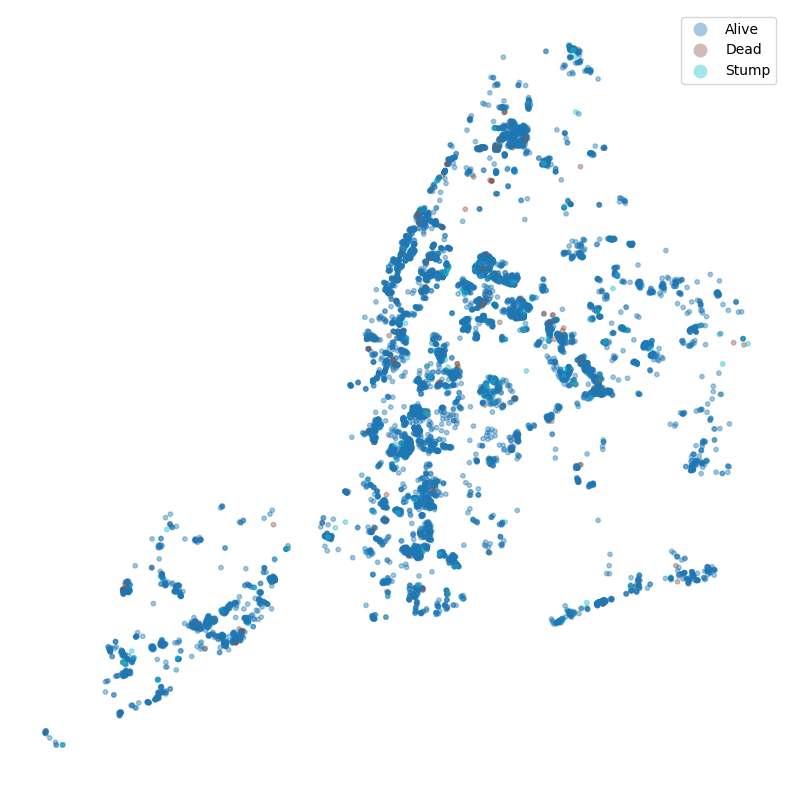

In [14]:
import matplotlib.pyplot as plt

f,ax = plt.subplots(1,1,figsize=(10,10))

gdf.plot(ax=ax, column = 'status', legend = True, markersize = 10, alpha = 0.4)
ax.axis('off')

# Urban greenery assesment

In [15]:
import pandas as pd
df = pd.read_csv('New_York_City_Population_By_Neighborhood_Tabulation_Areas_20240618.csv')
import geopandas as gpd
gdf = gpd.read_file('2010 Neighborhood Tabulation Areas (NTAs).geojson')
gdf_merged = gdf.merge(df, right_on = 'NTA Code',left_on = 'ntacode')
tdf = pd.read_csv('2015_Street_Tree_Census_-_Tree_Data_20240618.csv', nrows = 10000)

In [16]:
gdf_merged.head(3)

,ntacode,shape_area,county_fips,ntaname,shape_leng,boro_name,boro_code,geometry,Borough,Year,FIPS County Code,NTA Code,NTA Name,Population
0,QN08,77412747.756,081,St. Albans,45401.3169155,Queens,4,"MULTIPOLYGON (((-73.75205 40.70523, -73.75174 ...",Queens,2000,81,QN08,St. Albans,50046
1,QN08,77412747.756,081,St. Albans,45401.3169155,Queens,4,"MULTIPOLYGON (((-73.75205 40.70523, -73.75174 ...",Queens,2010,81,QN08,St. Albans,48593
2,BK50,82089678.5561,047,Canarsie,43703.6099368,Brooklyn,3,"MULTIPOLYGON (((-73.88834 40.64671, -73.88835 ...",Brooklyn,2000,47,BK50,Canarsie,85058


In [18]:
tdf = gpd.GeoDataFrame(tdf, geometry = geometry)[['tree_id','stump_diam','status','health','geometry']]

In [23]:
tdf.crs = 4326

In [24]:
tdf.head(3)

,tree_id,stump_diam,status,health,geometry
0,180683,0,Alive,Fair,POINT (-73.84422 40.72309)
1,200540,0,Alive,Fair,POINT (-73.81868 40.79411)
2,204026,0,Alive,Good,POINT (-73.93661 40.71758)


In [25]:
gdf_join = gpd.sjoin(gdf_merged,tdf)
gdf_join.head(3)

,ntacode,shape_area,county_fips,ntaname,shape_leng,boro_name,boro_code,geometry,Borough,Year,FIPS County Code,NTA Code,NTA Name,Population,index_right,tree_id,stump_diam,status,health
0,QN08,77412747.756,081,St. Albans,45401.3169155,Queens,4,"MULTIPOLYGON (((-73.75205 40.70523, -73.75174 ...",Queens,2000,81,QN08,St. Albans,50046,3004,147003,0,Alive,Good
0,QN08,77412747.756,081,St. Albans,45401.3169155,Queens,4,"MULTIPOLYGON (((-73.75205 40.70523, -73.75174 ...",Queens,2000,81,QN08,St. Albans,50046,9227,146045,0,Alive,Fair
0,QN08,77412747.756,081,St. Albans,45401.3169155,Queens,4,"MULTIPOLYGON (((-73.75205 40.70523, -73.75174 ...",Queens,2000,81,QN08,St. Albans,50046,726,147009,0,Alive,Fair


In [26]:
gdf_join = gdf_join[['NTA Name', 'Population', 'tree_id','geometry']]
gdf_join.head(3)

,NTA Name,Population,tree_id,geometry
0,St. Albans,50046,147003,"MULTIPOLYGON (((-73.75205 40.70523, -73.75174 ..."
0,St. Albans,50046,146045,"MULTIPOLYGON (((-73.75205 40.70523, -73.75174 ..."
0,St. Albans,50046,147009,"MULTIPOLYGON (((-73.75205 40.70523, -73.75174 ..."


In [27]:
gdf_grouped = gdf_join.groupby(by = 'NTA Name').nunique()[['tree_id']]
gdf_grouped = gdf_grouped.rename(columns = {'tree_id' : 'tree_count'})
gdf_grouped

,tree_count
NTA Name,
Allerton-Pelham Gardens,2
Annadale-Huguenot-Prince's Bay-Eltingville,100
Arden Heights,131
Astoria,184
Auburndale,13
...,...
Yorkville,90
park-cemetery-etc-Bronx,2
park-cemetery-etc-Brooklyn,34


In [28]:
gdf_join_tree = gdf_merged.merge(gdf_grouped, left_on = 'NTA Name', right_index = True)
gdf_join_tree.head(3)

,ntacode,shape_area,county_fips,ntaname,shape_leng,boro_name,boro_code,geometry,Borough,Year,FIPS County Code,NTA Code,NTA Name,Population,tree_count
0,QN08,77412747.756,081,St. Albans,45401.3169155,Queens,4,"MULTIPOLYGON (((-73.75205 40.70523, -73.75174 ...",Queens,2000,81,QN08,St. Albans,50046,16
1,QN08,77412747.756,081,St. Albans,45401.3169155,Queens,4,"MULTIPOLYGON (((-73.75205 40.70523, -73.75174 ...",Queens,2010,81,QN08,St. Albans,48593,16
2,BK50,82089678.5561,047,Canarsie,43703.6099368,Brooklyn,3,"MULTIPOLYGON (((-73.88834 40.64671, -73.88835 ...",Brooklyn,2000,47,BK50,Canarsie,85058,13


In [29]:
gdf_join_tree['trees_per_capita'] = gdf_join_tree['tree_count'] / gdf_join_tree['Population']
gdf_join_tree = gdf_join_tree.sort_values(by = 'trees_per_capita', ascending = False)

In [31]:
gdf_join_tree[['NTA Name','tree_count','Population','trees_per_capita']].head(10)

,NTA Name,tree_count,Population,trees_per_capita
230,park-cemetery-etc-Brooklyn,34,93,0.365591
231,park-cemetery-etc-Brooklyn,34,418,0.081340
382,park-cemetery-etc-Manhattan,33,1662,0.019856
383,park-cemetery-etc-Manhattan,33,1849,0.017847
171,Oakwood-Oakwood Beach,286,22049,0.012971
170,Oakwood-Oakwood Beach,286,22266,0.012845
155,Steinway,517,47534,0.010876
154,Steinway,517,53604,0.009645
271,Kew Gardens,189,23278,0.008119
270,Kew Gardens,189,23888,0.007912


<Axes: >

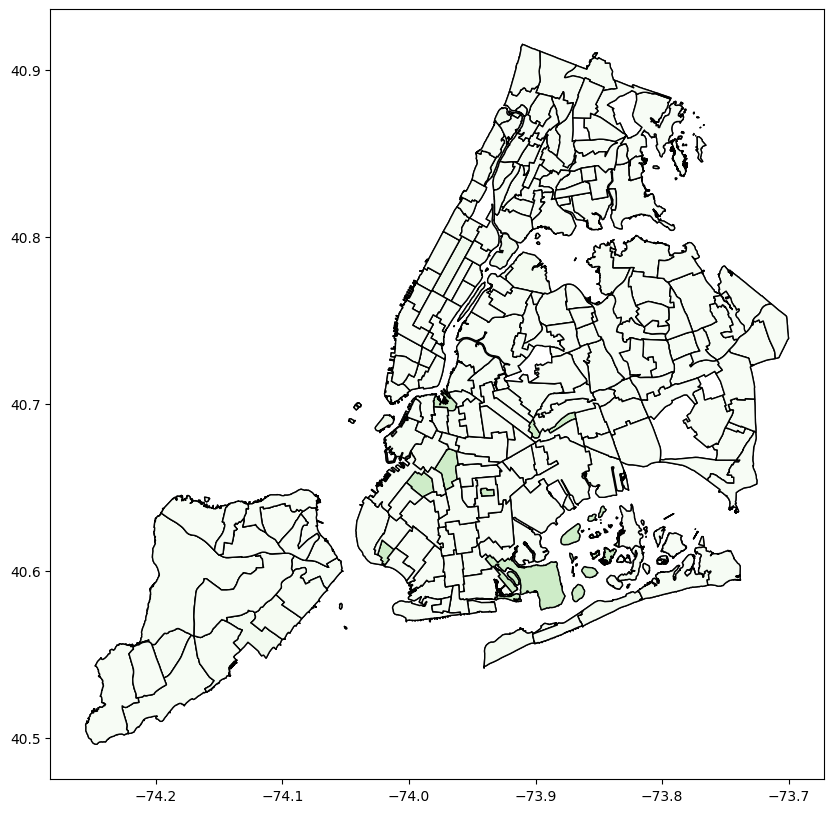

In [34]:
import matplotlib.pyplot as plt

f, ax = plt.subplots(1,1,figsize=(10,10))

gdf_join_tree.plot(ax=ax, column = 'trees_per_capita', cmap = 'Greens', edgecolor = 'k')

(np.float64(-74.28337047814922),
 np.float64(-73.67222994821337),
 np.float64(40.47516404814219),
 np.float64(40.93650271647436))

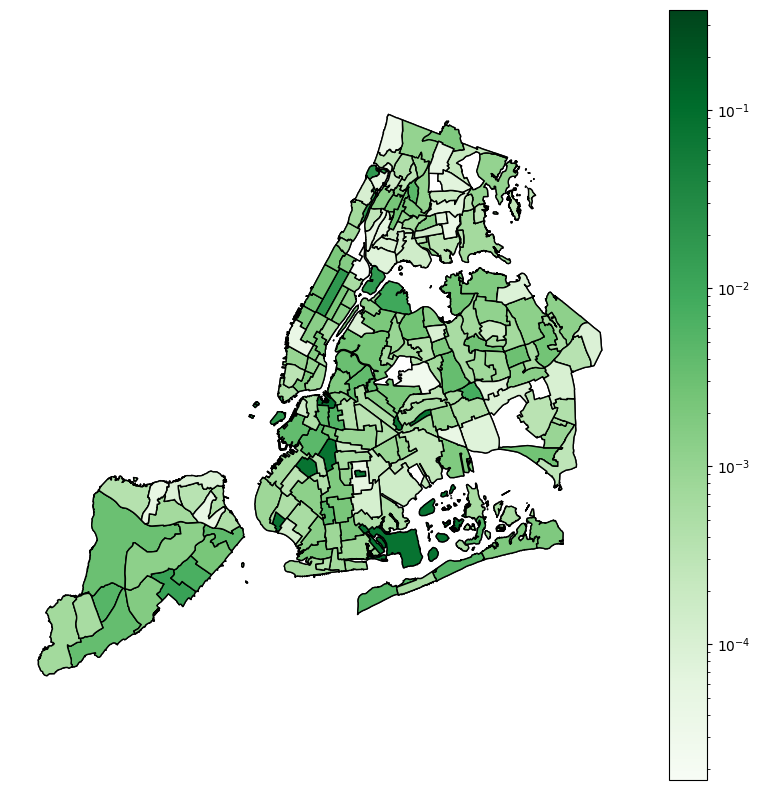

In [29]:
from matplotlib.colors import LogNorm

norm = LogNorm(vmin = gdf_join_tree['trees_per_capita'].min(),
               vmax = gdf_join_tree['trees_per_capita'].max())


f,ax = plt.subplots(1,1,figsize=(10,10))

gdf_join_tree.plot(ax=ax,
                   column = 'trees_per_capita',
                   cmap = 'Greens',
                   edgecolor = 'k',
                   norm = norm,
                   legend = True)

ax.axis('off')